In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
jsds = pd.read_csv('../data/jsd_analysis_results.csv')
jsds

,Analysis,Model,Lambda,JSD
0,Aggr: Catalog vs History,NaN,NaN,0.000239
1,User Level Mean: P^u vs Catalog,NaN,NaN,0.033283
2,User Level Median: P^u vs Catalog,NaN,NaN,0.025152
3,User Level Standard Deviation: P^u vs Catalog,NaN,NaN,0.029483
4,Aggr: Catalog vs Recs,BPR,0.0,0.007677
5,User Level Mean: P^u vs R^u,BPR,0.0,0.119625
6,Aggr: Catalog vs Recs,BPR,1.0,0.001871
7,User Level Mean: P^u vs R^u,BPR,1.0,0.022778
8,Aggr: Catalog vs Recs,ItemKNN,0.0,0.003173
9,User Level Mean: P^u vs R^u,ItemKNN,0.0,0.107960


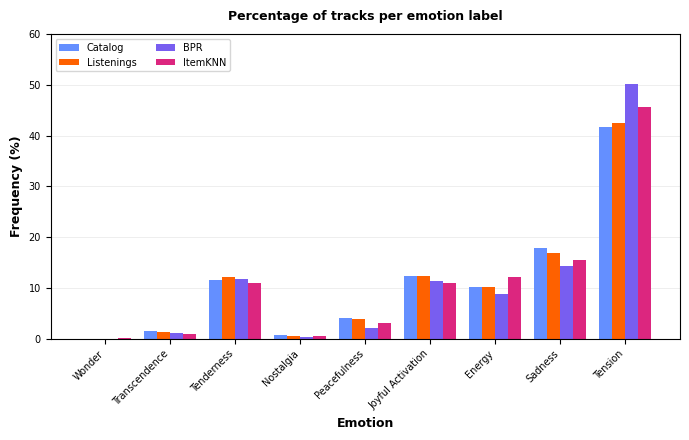

In [3]:
# Read the data
df = pd.read_csv('../data/dist_catalog_vs_history.csv')

# Define emotion labels
emotion_labels = {
    0: 'Wonder',
    1: 'Transcendence',
    2: 'Tenderness',
    3: 'Nostalgia',
    4: 'Peacefulness',
    5: 'Joyful Activation',
    6: 'Energy',
    7: 'Sadness',
    8: 'Tension'
}

# Convert to percentages
df['catalog_pct'] = df['catalog'] * 100
df['history_pct'] = df['history_aggr'] * 100
df['bpr_lambda0_pct'] = df['bpr_lambda0'] * 100
df['itemknn_lambda0_pct'] = df['itemknn_lambda0'] * 100

# Set up colorblind-friendly colors (using IBM Design color palette)
catalog_color = '#648FFF'  # Light Blue
listening_color = '#FE6100'  # Vivid Orange
bpr_color = '#785EF0'  # Purple
itemknn_color = '#DC267F'  # Magenta

# Create figure
fig, ax = plt.subplots(figsize=(7, 4.5))

# Set up x-axis positions for grouped bars
x = np.arange(len(df))
width = 0.2  # Width of each bar

# Create bars for all four distributions  λ=0
bars1 = ax.bar(x - 1.5*width, df['catalog_pct'], width, label='Catalog', color=catalog_color)
bars2 = ax.bar(x - 0.5*width, df['history_pct'], width, label='Listenings', color=listening_color)
bars3 = ax.bar(x + 0.5*width, df['bpr_lambda0_pct'], width, label='BPR', color=bpr_color)
bars4 = ax.bar(x + 1.5*width, df['itemknn_lambda0_pct'], width, label='ItemKNN', color=itemknn_color)

# Add horizontal grid lines every 10%
max_val = max(df['catalog_pct'].max(), df['history_pct'].max(), 
              df['bpr_lambda0_pct'].max(), df['itemknn_lambda0_pct'].max())
ax.set_yticks(np.arange(0, max_val + 10, 10))
ax.grid(axis='y', alpha=0.3, linestyle='-', linewidth=0.5)
ax.set_axisbelow(True)

# Customize plot
ax.set_xlabel('Emotion', fontsize=9, fontweight='bold')
ax.set_ylabel('Frequency (%)', fontsize=9, fontweight='bold')
ax.set_title('Percentage of tracks per emotion label', 
             fontsize=9, fontweight='bold', pad=10)
ax.set_xticks(x)
ax.set_xticklabels([emotion_labels[i] for i in df['emotion']], rotation=45, ha='right', fontsize=7)
ax.tick_params(axis='y', labelsize=7)
ax.legend(fontsize=7, ncol=2, loc='upper left')

plt.tight_layout()
plt.savefig('../figures/combined_histogram.png', dpi=300)
plt.show()

In [4]:
# Transposed table: emotions as columns, models/sources as rows with comparisons
transposed_table = pd.DataFrame()

# Create emotion columns
emotion_names = [emotion_labels[i] for i in df['emotion']]

# Prepare all rows
rows = []
row_labels = []

# For each source, add three rows: distribution, vs Catalog, vs Listenings
sources = [
    ('Catalog', df['catalog_pct']),
    ('Listenings', df['history_pct']),
    ('BPR (λ=0)', df['bpr_lambda0_pct']),
    ('ItemKNN (λ=0)', df['itemknn_lambda0_pct'])
]

for source_name, source_data in sources:
    # Row 1: Distribution (as decimal)
    dist_row = [f"{source_data.iloc[idx]/100:.4f}" for idx, _ in enumerate(emotion_names)]
    rows.append(dist_row)
    row_labels.append(f"{source_name}")
    
    # Row 2: vs Catalog (as percentage)
    if source_name == 'Catalog':
        vs_catalog_row = ['—' for _ in emotion_names]
    else:
        vs_catalog_row = [
            f"{((source_data.iloc[idx] - df['catalog_pct'].iloc[idx]) / df['catalog_pct'].iloc[idx] * 100):+.1f}%"
            for idx, _ in enumerate(emotion_names)
        ]
    rows.append(vs_catalog_row)
    row_labels.append(f"  vs Catalog")
    
    # Row 3: vs Listenings (as percentage)
    if source_name == 'Listenings':
        vs_list_row = ['—' for _ in emotion_names]
    else:
        vs_list_row = [
            f"{((source_data.iloc[idx] - df['history_pct'].iloc[idx]) / df['history_pct'].iloc[idx] * 100):+.1f}%"
            for idx, _ in enumerate(emotion_names)
        ]
    rows.append(vs_list_row)
    row_labels.append(f"  vs Listenings")

# Create dataframe
transposed_table = pd.DataFrame(rows, columns=emotion_names, index=row_labels)
transposed_table.index.name = 'Source'

print("\nEmotion Distribution: Frequencies and Relative Differences")
print("=" * 140)
print("Each source has three rows:")
print("  1) Distribution (proportion of tracks)")
print("  2) vs Catalog: % change relative to catalog baseline")
print("  3) vs Listenings: % change relative to user listening history")
print("=" * 140)
display(transposed_table)

# Also save to CSV for potential use in papers
transposed_table.to_csv('../data/emotion_distribution_transposed.csv')
print("\nTable saved to: ../data/emotion_distribution_transposed.csv")


Emotion Distribution: Frequencies and Relative Differences
Each source has three rows:
  1) Distribution (proportion of tracks)
  2) vs Catalog: % change relative to catalog baseline
  3) vs Listenings: % change relative to user listening history


,Wonder,Transcendence,Tenderness,Nostalgia,Peacefulness,Joyful Activation,Energy,Sadness,Tension
Source,,,,,,,,,
Catalog,0.0005,0.0148,0.1158,0.0067,0.0414,0.1234,0.1027,0.1785,0.4163
vs Catalog,—,—,—,—,—,—,—,—,—
vs Listenings,+6.8%,+4.1%,-5.5%,+14.9%,+5.8%,+0.4%,+1.1%,+5.6%,-1.9%
Listenings,0.0005,0.0142,0.1225,0.0058,0.0392,0.1229,0.1016,0.1691,0.4242
vs Catalog,-6.4%,-3.9%,+5.8%,-12.9%,-5.4%,-0.4%,-1.1%,-5.3%,+1.9%
vs Listenings,—,—,—,—,—,—,—,—,—
BPR (λ=0),0.0002,0.0112,0.1170,0.0033,0.0217,0.1138,0.0884,0.1431,0.5013
vs Catalog,-58.3%,-24.5%,+1.0%,-50.2%,-47.6%,-7.7%,-13.9%,-19.8%,+20.4%
vs Listenings,-55.5%,-21.4%,-4.5%,-42.8%,-44.5%,-7.4%,-13.0%,-15.4%,+18.2%



Table saved to: ../data/emotion_distribution_transposed.csv


In [5]:
# Convert to LaTeX - escape % signs
# First, create a copy with escaped percentages
transposed_table_latex = transposed_table.copy()
for col in transposed_table_latex.columns:
    transposed_table_latex[col] = transposed_table_latex[col].apply(lambda x: x.replace('%', r'\%'))

latex_output = transposed_table_latex.to_latex(
    escape=False,
    column_format='l' + 'r' * len(emotion_names),
    caption='Emotion distribution frequencies and relative differences',
    label='tab:emotion_distribution'
)

print(latex_output)

# Save LaTeX to file
with open('../data/emotion_distribution_table.tex', 'w') as f:
    f.write(latex_output)
    
print("\nLaTeX table saved to: ../data/emotion_distribution_table.tex")

\begin{table}
\caption{Emotion distribution frequencies and relative differences}
\label{tab:emotion_distribution}
\begin{tabular}{lrrrrrrrrr}
\toprule
 & Wonder & Transcendence & Tenderness & Nostalgia & Peacefulness & Joyful Activation & Energy & Sadness & Tension \\
Source &  &  &  &  &  &  &  &  &  \\
\midrule
Catalog & 0.0005 & 0.0148 & 0.1158 & 0.0067 & 0.0414 & 0.1234 & 0.1027 & 0.1785 & 0.4163 \\
  vs Catalog & — & — & — & — & — & — & — & — & — \\
  vs Listenings & +6.8\% & +4.1\% & -5.5\% & +14.9\% & +5.8\% & +0.4\% & +1.1\% & +5.6\% & -1.9\% \\
Listenings & 0.0005 & 0.0142 & 0.1225 & 0.0058 & 0.0392 & 0.1229 & 0.1016 & 0.1691 & 0.4242 \\
  vs Catalog & -6.4\% & -3.9\% & +5.8\% & -12.9\% & -5.4\% & -0.4\% & -1.1\% & -5.3\% & +1.9\% \\
  vs Listenings & — & — & — & — & — & — & — & — & — \\
BPR (λ=0) & 0.0002 & 0.0112 & 0.1170 & 0.0033 & 0.0217 & 0.1138 & 0.0884 & 0.1431 & 0.5013 \\
  vs Catalog & -58.3\% & -24.5\% & +1.0\% & -50.2\% & -47.6\% & -7.7\% & -13.9\% & -19.8\% & +20.

In [6]:
results = pd.read_csv('../data/comparison_study_results.csv')
results.head()

,Model,Method,Lambda,nDCG,nDCG_std,JSD,JSD_std,KL,KL_std
0,BPR,Greedy (Calibrated),0.0,0.681029,0.281643,0.119625,0.061008,3.860525,2.521727
1,BPR,Greedy (Calibrated),0.5,0.681630,0.281417,0.084633,0.046320,2.482210,1.873521
2,BPR,Greedy (Calibrated),1.0,0.668898,0.269903,0.021605,0.010701,0.490344,0.436171
3,BPR,Linear heuristic,0.0,0.681029,0.281643,0.119625,0.061008,3.860525,2.521727
4,BPR,Linear heuristic,0.5,0.679375,0.281295,0.071965,0.038368,2.060233,1.574023


In [ ]:
results['Method'] = results['Method'].replace({
        'Greedy (Calibrated)': 'Rec. Score',
        'Linear heuristic': 'Rank Score'
    })

# Convert std to standard error: SE = std / sqrt(n)
n = 14040
results['nDCG_se'] = results['nDCG_std'] / np.sqrt(n)
results['JSD_se'] = results['JSD_std'] / np.sqrt(n)
results['KL_se'] = results['KL_std'] / np.sqrt(n)

In [8]:
results_small = results[results.Lambda.isin([0.0, 0.5, 1.0])]

# Pivot the data to have Rec. Score and Rank Score side by side
rec_score = results_small[results_small['Method'] == 'Rec. Score'][['Model', 'Lambda', 'nDCG', 'nDCG_se', 'JSD', 'JSD_se']]
rank_score = results_small[results_small['Method'] == 'Rank Score'][['Model', 'Lambda', 'nDCG', 'nDCG_se', 'JSD', 'JSD_se']]

# Rename columns to distinguish between methods
rec_score = rec_score.rename(columns={
    'nDCG': 'nDCG (Rec)', 'nDCG_se': 'nDCG SE (Rec)',
    'JSD': 'JSD (Rec)', 'JSD_se': 'JSD SE (Rec)'
})
rank_score = rank_score.rename(columns={
    'nDCG': 'nDCG (Rank)', 'nDCG_se': 'nDCG SE (Rank)',
    'JSD': 'JSD (Rank)', 'JSD_se': 'JSD SE (Rank)'
})

# Merge on Model and Lambda
results_reformatted = rec_score.merge(rank_score, on=['Model', 'Lambda'])

# Set display options to show 4 decimal places
pd.options.display.float_format = '{:.4f}'.format

results_reformatted

,Model,Lambda,nDCG (Rec),nDCG SE (Rec),JSD (Rec),JSD SE (Rec),nDCG (Rank),nDCG SE (Rank),JSD (Rank),JSD SE (Rank)
0,BPR,0.0000,0.6810,0.0024,0.1196,0.0005,0.6810,0.0024,0.1196,0.0005
1,BPR,0.5000,0.6816,0.0024,0.0846,0.0004,0.6794,0.0024,0.0720,0.0003
2,BPR,1.0000,0.6689,0.0023,0.0216,0.0001,0.6689,0.0023,0.0216,0.0001
3,ItemKNN,0.0000,0.7968,0.0023,0.1080,0.0005,0.7968,0.0023,0.1080,0.0005
4,ItemKNN,0.5000,0.7991,0.0023,0.0835,0.0004,0.7982,0.0023,0.0679,0.0003
5,ItemKNN,1.0000,0.7795,0.0022,0.0225,0.0001,0.7784,0.0022,0.0216,0.0001
6,MostPop,0.0000,0.2521,0.0029,0.0662,0.0003,0.2521,0.0029,0.0662,0.0003
7,MostPop,0.5000,0.2516,0.0029,0.0661,0.0003,0.2457,0.0029,0.0633,0.0002
8,MostPop,1.0000,0.2377,0.0027,0.0219,0.0001,0.2377,0.0027,0.0219,0.0001


In [9]:
# Print the reformatted table in LaTeX format
latex_str = results_reformatted.to_latex(
    index=False, 
    formatters={
        'Lambda': lambda x: f'{x:.1f}',
        'nDCG (Rec)': lambda x: f'{x:.4f}',
        'nDCG SE (Rec)': lambda x: f'{x:.4f}',
        'JSD (Rec)': lambda x: f'{x:.4f}',
        'JSD SE (Rec)': lambda x: f'{x:.4f}',
        'nDCG (Rank)': lambda x: f'{x:.4f}',
        'nDCG SE (Rank)': lambda x: f'{x:.4f}',
        'JSD (Rank)': lambda x: f'{x:.4f}',
        'JSD SE (Rank)': lambda x: f'{x:.4f}'
    }
)
print(latex_str)

\begin{tabular}{lrrrrrrrrr}
\toprule
Model & Lambda & nDCG (Rec) & nDCG SE (Rec) & JSD (Rec) & JSD SE (Rec) & nDCG (Rank) & nDCG SE (Rank) & JSD (Rank) & JSD SE (Rank) \\
\midrule
BPR & 0.0 & 0.6810 & 0.0024 & 0.1196 & 0.0005 & 0.6810 & 0.0024 & 0.1196 & 0.0005 \\
BPR & 0.5 & 0.6816 & 0.0024 & 0.0846 & 0.0004 & 0.6794 & 0.0024 & 0.0720 & 0.0003 \\
BPR & 1.0 & 0.6689 & 0.0023 & 0.0216 & 0.0001 & 0.6689 & 0.0023 & 0.0216 & 0.0001 \\
ItemKNN & 0.0 & 0.7968 & 0.0023 & 0.1080 & 0.0005 & 0.7968 & 0.0023 & 0.1080 & 0.0005 \\
ItemKNN & 0.5 & 0.7991 & 0.0023 & 0.0835 & 0.0004 & 0.7982 & 0.0023 & 0.0679 & 0.0003 \\
ItemKNN & 1.0 & 0.7795 & 0.0022 & 0.0225 & 0.0001 & 0.7784 & 0.0022 & 0.0216 & 0.0001 \\
MostPop & 0.0 & 0.2521 & 0.0029 & 0.0662 & 0.0003 & 0.2521 & 0.0029 & 0.0662 & 0.0003 \\
MostPop & 0.5 & 0.2516 & 0.0029 & 0.0661 & 0.0003 & 0.2457 & 0.0029 & 0.0633 & 0.0002 \\
MostPop & 1.0 & 0.2377 & 0.0027 & 0.0219 & 0.0001 & 0.2377 & 0.0027 & 0.0219 & 0.0001 \\
\bottomrule
\end{tabular}



In [10]:
# Load the tsv file
df = pd.read_csv('/opt/datasets/Music4All/music4all/id_gems.tsv', sep='\t')

# Set the 'id' column as the index
df.set_index('id', inplace=True)

# Find the column with the maximum value for each row
df['highest_gem'] = df.idxmax(axis=1)

# Reset the index to get the 'id' column back
df.reset_index(inplace=True)

# Keeping only the 'id' and 'highest_gem' columns
result_df = df[['id', 'highest_gem']]


In [11]:
result_df.head()

,id,highest_gem
0,04q3VppIQEET5rzy,6
1,07xF9Q0K1t3ist7K,8
2,0JbYcELIqpMPvAHk,1
3,0Ki5X2aXeT39ibBA,7
4,0Nf4VEOSVFUp6D6z,4


In [12]:
result_df.highest_gem.value_counts()

highest_gem
8    45485
7    19501
5    13479
2    12649
6    11220
4     4529
1     1615
3      733
0       56
Name: count, dtype: int64

<Axes: >

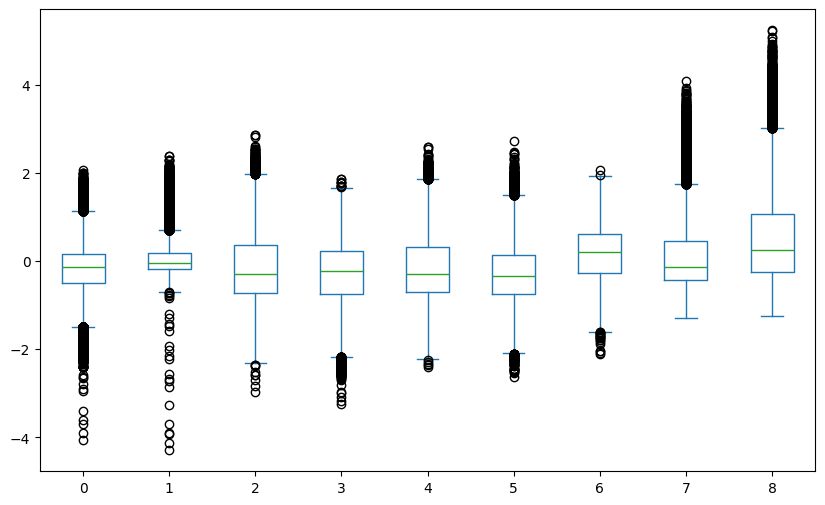

In [13]:
df.plot(kind='box', figsize=(10, 6))  # Box plot alternative